In [7]:
!pip install lisagwresponse

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip3 install --upgrade pip


In [8]:
%pip install lisagwresponse

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
%pip install lisa-data-challenge

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
%pip install --upgrade astropy

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as un
from scipy.interpolate import InterpolatedUnivariateSpline
from ldc.waveform.waveform import HpHc
from ldc.lisa.orbits import Orbits
from ldc.lisa.projection.projectedstrain import ProjectedStrain
from ldc.lisa.noise import get_noise_model
import utils_signal as usig
import utils_grb_aft_new as ugrb

class NumericWaveform(HpHc):
    """Classe pour gérer un signal h(t) fourni sous forme de tableaux NumPy."""
    def set_param(self, param, units=None):
        self.p = param
        for key, value in param.items():
            setattr(self, key, value)
        if 'basis' in self.p:
            self.basis = self.p['basis']
        self.check_param()
        
    def check_param(self):
        needed = ['t', 'hp', 'hc'] 
        if not all(k in self.p for k in needed):
            raise ValueError(f"Paramètres manquants. {needed} sont requis.")
        self.hp_interp = InterpolatedUnivariateSpline(self.p['t'], self.p['hp'], ext='zeros')
        self.hc_interp = InterpolatedUnivariateSpline(self.p['t'], self.p['hc'], ext='zeros') 
        
    def compute_hphc_td(self, t, **kwargs):
        hp_t = self.hp_interp(t)
        hc_t = self.hc_interp(t) 
        return hp_t, hc_t

def plot_tdi_vs_noise(freqs, tdi_X, tdi_Y, tdi_Z, dt):
    """
    Calcule la FFT des variables TDI et les affiche avec le bruit LISA.
    """
    # FFT des signaux TDI[cite: 2]
    tilde_X = np.fft.rfft(tdi_X) * dt
    tilde_Y = np.fft.rfft(tdi_Y) * dt
    tilde_Z = np.fft.rfft(tdi_Z) * dt
    
    # Modèle de bruit LISA[cite: 2]
    noise_model = get_noise_model("SciRDv1", freqs)
    Sn_X = noise_model.psd(option='X')
    
    plt.figure(figsize=(10, 6))
    plt.loglog(freqs, np.sqrt(Sn_X), label="Bruit LISA (TDI X)", color='black', lw=2)
    plt.loglog(freqs, np.abs(tilde_X), label="|TDI X|", alpha=0.7)
    plt.loglog(freqs, np.abs(tilde_Y), label="|TDI Y|", alpha=0.7)
    plt.loglog(freqs, np.abs(tilde_Z), label="|TDI Z|", alpha=0.7)
    
    plt.title("Signal TDI et Bruit LISA")
    plt.xlabel("Fréquence (Hz)")
    plt.ylabel("Strain (1/√Hz)")
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.show()

def calculate_lisa_snr_for_grb(E_GRB, T_90, E_aft, beta, t_dec, t_jet_break, d, theta, theta_j, t_max=50000, dt=0.1):
    """
    Fonction unique qui génère le signal GRB, le projette sur LISA, 
    calcule les TDI et retourne le SNR.
    """
    # 1. Grille temporelle
    t = np.arange(0, t_max, dt)
    
    # 2. Génération du signal temporel via le modèle[cite: 1]
    hp, hp_GRB, hp_aft = ugrb.grb_afterglow_model(t, E_GRB, T_90, E_aft, beta, t_dec, t_jet_break, d, theta, theta_j)
    hc = np.zeros_like(t)
    # plot du signal pour vérification
    plt.figure(figsize=(10, 4))
    plt.plot(t, hp, label='hp (GRB + Afterglow)', color='blue')
    plt.title("Signal temporel hp du GRB et de son afterglow")
    plt.xlabel("Temps (s)")
    plt.ylabel("Strain hp")
    plt.grid()
    plt.legend()
    plt.show()
    print(f'Amplitude maximale du signal hp: {np.max(np.abs(hp)):.2e}, amplitude du grb: {hp_GRB:.2e}, amplitude de l\'afterglow: {hp_aft:.2e}')
    
    # 3. Configuration de la source numérique
    k, u, v = np.array([0., 0., 1.]), np.array([1., 0., 0.]), np.array([0., 1., 0.])
    gw_source = NumericWaveform("grb_memory", "Numeric", "TD")
    gw_source.set_param({'t': t, 'hp': hp, 'hc': hc, 'd_L': d * un.pc, 'basis': (k, v, u)})
    
    # 4. Configuration des orbites et projection
    config = {"orbit_type": "analytic", "nominal_arm_length": 2.5e9 * un.m, "initial_rotation": 0 * un.rad, "initial_position": 0 * un.rad}
    orbits = Orbits.type(config)
    proj = ProjectedStrain(orbits)
    
    # Projection sur les bras
    yArm = proj.arm_response(0, t_max, dt, GWs=[gw_source])
    
    # 5. Calcul des variables TDI
    tdi_X = proj.compute_tdi_x(t)
    tdi_Y = proj.compute_tdi_y(t)
    tdi_Z = proj.compute_tdi_z(t)
    
    # Affichage rapide des TDI pour vérification
    plt.figure(figsize=(10, 6))
    plt.plot(t, tdi_X, label='TDI X', alpha=0.7)
    plt.plot(t, tdi_Y, label='TDI Y', alpha=0.7)
    plt.plot(t, tdi_Z, label='TDI Z', alpha=0.7)
    plt.title("Variables TDI avant padding")    
    plt.xlabel("Temps (s)")
    plt.ylabel("Strain")
    plt.grid()
    plt.legend()
    plt.show()
    
    
    # Pad and tapper the signal for spectral leakage reduction
    t_X, tdi_X_p = usig.pad_and_taper(tdi_X, t, padding_length=1000, window_type='tukey', alpha=0.2)
    t_Y, tdi_Y_p = usig.pad_and_taper(tdi_Y, t, padding_length=1000, window_type='tukey', alpha=0.2)
    t_Z, tdi_Z_p = usig.pad_and_taper(tdi_Z, t, padding_length=1000, window_type='tukey', alpha=0.2)

    # Vérification (doivent être identiques)
    assert (t_X == t_Y).all() and (t_X == t_Z).all(), "Les temps paddés ne sont pas identiques !"

    t = t_X
    tdi_X, tdi_Y, tdi_Z = tdi_X_p, tdi_Y_p, tdi_Z_p
    print(f"Shape après padding: {tdi_X.shape}, t shape: {t.shape}")
    # 6. Domaine fréquentiel et SNR
    freqs = np.fft.rfftfreq(len(t), d=dt)
    df = freqs[1] - freqs[0]
    
    
    tilde_X = np.fft.rfft(tdi_X) * dt
    tilde_Y = np.fft.rfft(tdi_Y) * dt
    tilde_Z = np.fft.rfft(tdi_Z) * dt
    
    # Plot pour vérification
    plt.figure(figsize=(10, 6))
    plt.loglog(freqs, np.abs(tilde_X), label="|TDI X| après padding", alpha=0.7)
    plt.loglog(freqs, np.abs(tilde_Y), label="|TDI Y| après padding", alpha=0.7)
    plt.loglog(freqs, np.abs(tilde_Z), label="|TDI Z| après padding", alpha=0.7)
    plt.title("FFT des TDI après padding")
    plt.xlabel("Fréquence (Hz)")
    plt.ylabel("Strain (1/√Hz)")
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.show()
    
    noise_model = get_noise_model("SciRDv1", freqs)
    Sn_X = noise_model.psd(option='X')
    Sn_Y = noise_model.psd(option='X')
    Sn_Z = noise_model.psd(option='X')

    plot_tdi_vs_noise(freqs, tdi_X, tdi_Y, tdi_Z, dt)
    
    # compute the snr for frequency between 5e-5 and 1 Hz
    valid_freqs = (freqs >= 5e-5) & (freqs <= 1)
    freqs = freqs[valid_freqs]
    tilde_X = tilde_X[valid_freqs]
    tilde_Y = tilde_Y[valid_freqs]
    tilde_Z = tilde_Z[valid_freqs]
    Sn_X = Sn_X[valid_freqs]
    Sn_Y = Sn_Y[valid_freqs]
    Sn_Z = Sn_Z[valid_freqs]
    
    # Calcul SNR^2 = 4 * sum(|h_tilde|^2 / Sn) * df
    snr2_X = 4 * np.sum(np.abs(tilde_X)**2 / Sn_X) * df
    snr2_Y = 4 * np.sum(np.abs(tilde_Y)**2 / Sn_Y) * df
    snr2_Z = 4 * np.sum(np.abs(tilde_Z)**2 / Sn_Z) * df
    
    snr_total = np.sqrt(snr2_X + snr2_Y + snr2_Z)

    print(f"--- Résultats SNR LISA ---")
    print(f"SNR X: {np.sqrt(snr2_X):.2f}")
    print(f"SNR Y: {np.sqrt(snr2_Y):.2f}")
    print(f"SNR Z: {np.sqrt(snr2_Z):.2f}")
    print(f"SNR Total combiné: {snr_total:.2e}")
    
    return snr_total



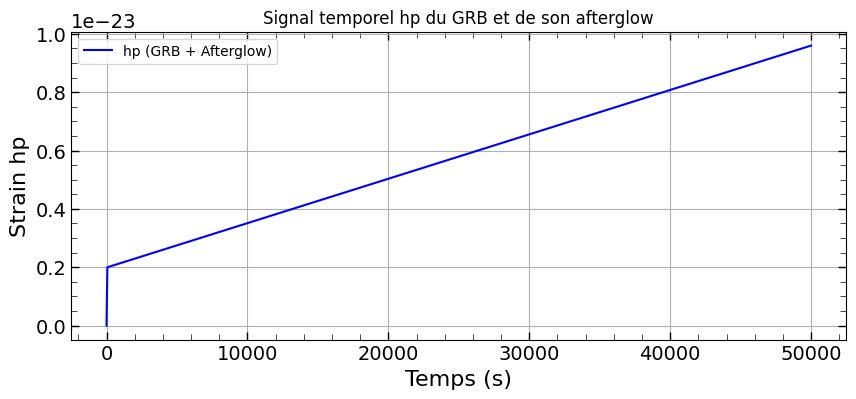

Amplitude maximale du signal hp: 9.60e-24, amplitude du grb: 2.00e-24, amplitude de l'afterglow: 1.31e-23


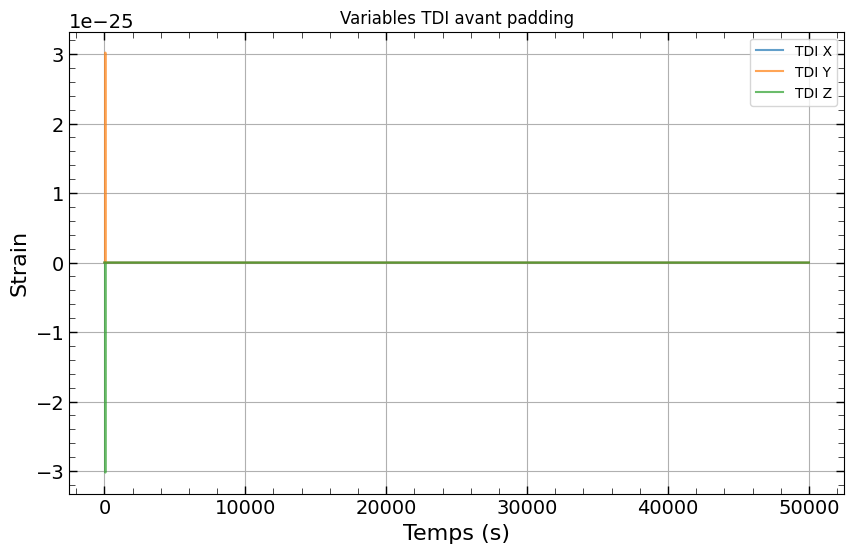

Shape après padding: (510000,), t shape: (510000,)


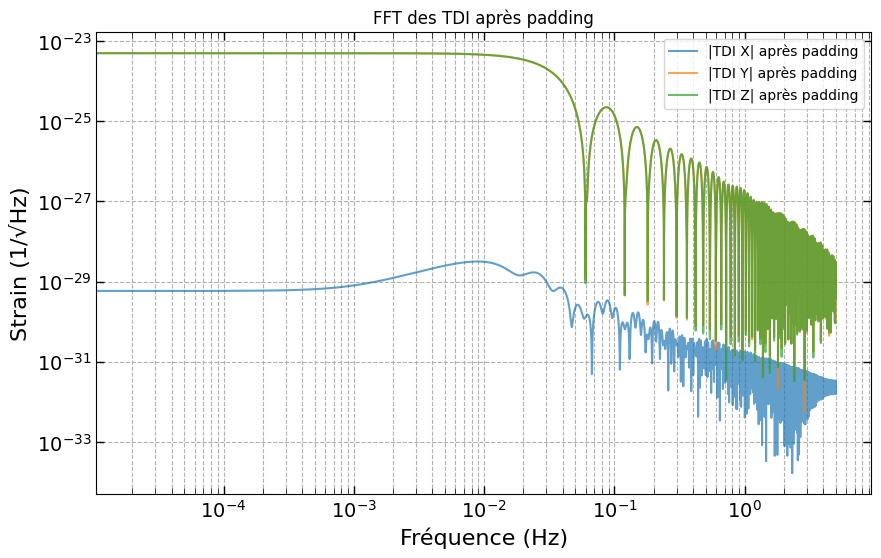

/opt/pycbc/.local/lib/python3.11/site-packages/ldc/lisa/noise/noise.py:302: RuntimeWarning: divide by zero encountered in divide
  sa_a = AnalyticNoise.psd_a_a[self.model] * (1.0 +(0.4e-3/frq)**2) *\
/opt/pycbc/.local/lib/python3.11/site-packages/ldc/lisa/noise/noise.py:304: RuntimeWarning: divide by zero encountered in power
  self.sa_d = sa_a*(2.*np.pi*frq)**(-4.) # in displacement
/opt/pycbc/.local/lib/python3.11/site-packages/ldc/lisa/noise/noise.py:305: RuntimeWarning: invalid value encountered in multiply
  sa_nu = self.sa_d*(2.0*np.pi*frq/CLIGHT)**2 # in rel freq unit
/opt/pycbc/.local/lib/python3.11/site-packages/ldc/lisa/noise/noise.py:309: RuntimeWarning: divide by zero encountered in divide
  relax = (1. + (2.e-3/frq)**4) if self.oms_relaxation else 1.0
/opt/pycbc/.local/lib/python3.11/site-packages/ldc/lisa/noise/noise.py:311: RuntimeWarning: invalid value encountered in multiply
  s_oms_nu = self.psd_oms_d*(2.0*np.pi*frq/CLIGHT)**2 # in rel freq unit
/opt/pycbc/.local/lib/

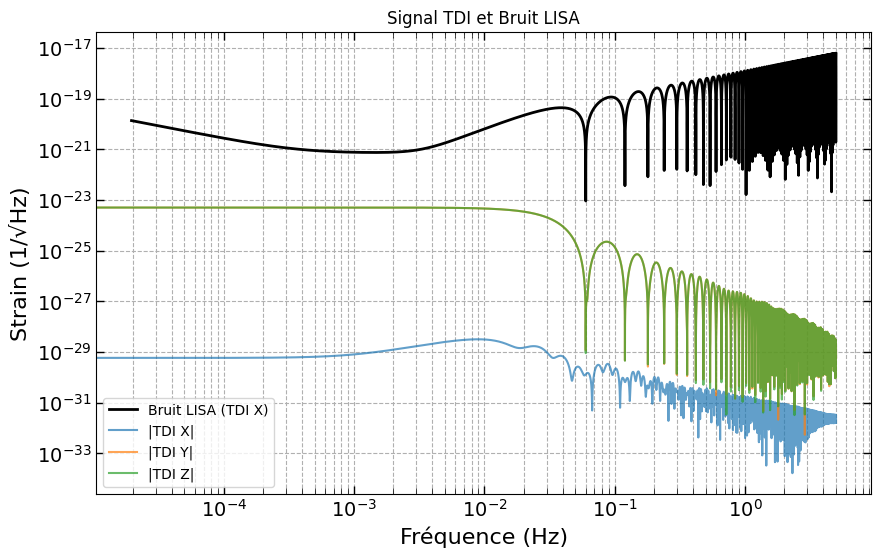

--- Résultats SNR LISA ---
SNR X: 0.00
SNR Y: 0.00
SNR Z: 0.00
SNR Total combiné: 1.11e-03


In [28]:
# Paramètres d'exemple pour un GRB
E_GRB_val, T_90_val = 7.6e51, 51.37
E_aft_val, beta_val = 5e52, 0.99
t_dec_val, t_jet_break_val = 50, 86400
d_val, theta_val, theta_j_val = 350.0*1e6, np.deg2rad(30), 100

snr_final = calculate_lisa_snr_for_grb(
    E_GRB_val, T_90_val, E_aft_val, beta_val, 
    t_dec_val, t_jet_break_val, d_val, theta_val, theta_j_val
)